# Explore here

# Predicción de dirección de precio — BTC/USDT

Siguiendo el flujo de Machine Learning de 4Geeks:

1. Definición del problema ✅
2. Obtención del conjunto de datos ✅
3. Almacenar la información ✅
4. **Análisis descriptivo** ← estamos aquí
5. EDA completo
6. Modelado y optimización
7. Despliegue

---

## Paso 4 — Análisis Descriptivo

Objetivo: **describir** las características principales del conjunto de datos
mediante estadísticas descriptivas (media, mediana, desviaciones, distribuciones),
y usar contrastes de hipótesis cuando sea necesario.

No exploramos relaciones ni tomamos decisiones sobre variables aún — eso viene en el EDA.

In [120]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [121]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### 4.1 Carga de datos

Cargamos las velas desde el CSV exportado en la fase de almacenamiento.

In [122]:
btc = pd.read_csv("../data/raw/BTCUSDT_1h.csv")
btc["datetime"] = pd.to_datetime(btc["open_time"], unit="ms")

In [123]:
print(f"Filas: {btc.shape[0]:,}")
print(f"Columnas: {btc.shape[1]}")
print(f"Rango temporal: {btc['datetime'].min()} → {btc['datetime'].max()}")
btc.head()

Filas: 35,033
Columnas: 14
Rango temporal: 2022-07-24 02:00:00 → 2026-07-23 01:00:00


,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,symbol,interval,datetime
0,1658628000000,1658631599999,22430.51,22480.00,22355.18,22475.01,40.499169,9.073818e+05,735,21.647849,4.850167e+05,BTCUSDT,1h,2022-07-24 02:00:00
1,1658631600000,1658635199999,22468.82,22474.12,22291.29,22329.94,29.289648,6.548479e+05,586,12.701257,2.839017e+05,BTCUSDT,1h,2022-07-24 03:00:00
2,1658635200000,1658638799999,22333.90,22408.92,22261.75,22394.78,50.960840,1.138502e+06,869,28.375770,6.339065e+05,BTCUSDT,1h,2022-07-24 04:00:00
3,1658638800000,1658642399999,22394.50,22781.02,22390.54,22742.03,108.767659,2.461210e+06,1907,56.865925,1.286572e+06,BTCUSDT,1h,2022-07-24 05:00:00
4,1658642400000,1658645999999,22749.98,22761.70,22631.40,22674.03,50.731979,1.151840e+06,1071,25.156869,5.712489e+05,BTCUSDT,1h,2022-07-24 06:00:00


### 4.2 Descripción general — tipos y estructura

Antes de calcular estadísticas, entendamos qué tipo de dato tiene cada columna
y confirmemos que no hay valores nulos.

In [124]:
btc.info()
print("\nValores nulos por columna:")
print(btc.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 35033 entries, 0 to 35032
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open_time               35033 non-null  int64         
 1   close_time              35033 non-null  int64         
 2   open                    35033 non-null  float64       
 3   high                    35033 non-null  float64       
 4   low                     35033 non-null  float64       
 5   close                   35033 non-null  float64       
 6   volume                  35033 non-null  float64       
 7   quote_asset_volume      35033 non-null  float64       
 8   number_of_trades        35033 non-null  int64         
 9   taker_buy_base_volume   35033 non-null  float64       
 10  taker_buy_quote_volume  35033 non-null  float64       
 11  symbol                  35033 non-null  str           
 12  interval                35033 non-null  str           
 1

### 4.3 Medidas estadísticas fundamentales

Calculamos las medidas clásicas para las variables numéricas más importantes:

- **Media** — valor promedio.
- **Mediana** — valor central (50% arriba, 50% abajo).
- **Desviación estándar** — dispersión respecto a la media.
- **Mínimo y máximo** — rango.
- **Asimetría (skew)** — si la distribución está inclinada a un lado.
- **Curtosis** — si tiene colas más pesadas que una distribución normal.

In [125]:
precio = btc["close"]

print("--- Precio de cierre (close) ---")
print(f"  Media:            {precio.mean():.2f}")
print(f"  Mediana:          {precio.median():.2f}")
print(f"  Desv. estándar:   {precio.std():.2f}")
print(f"  Mínimo:           {precio.min():.2f}")
print(f"  Máximo:           {precio.max():.2f}")
print(f"  Asimetría (skew): {precio.skew():.4f}")
print(f"  Curtosis:         {precio.kurt():.4f}")

--- Precio de cierre (close) ---
  Media:            61446.32
  Mediana:          63801.37
  Desv. estándar:   31587.04
  Mínimo:           15650.78
  Máximo:           125999.00
  Asimetría (skew): 0.1508
  Curtosis:         -1.2434


### 4.4 Medidas estadísticas del volumen

Repetimos las mismas medidas para la columna de volumen.

In [126]:
volumen = btc["volume"]

print("--- Volumen ---")
print(f"  Media:            {volumen.mean():.2f}")
print(f"  Mediana:          {volumen.median():.2f}")
print(f"  Desv. estándar:   {volumen.std():.2f}")
print(f"  Mínimo:           {volumen.min():.2f}")
print(f"  Máximo:           {volumen.max():.2f}")
print(f"  Asimetría (skew): {volumen.skew():.4f}")
print(f"  Curtosis:         {volumen.kurt():.4f}")

--- Volumen ---
  Media:            21.22
  Mediana:          1.63
  Desv. estándar:   62.67
  Mínimo:           0.00
  Máximo:           2004.51
  Asimetría (skew): 8.5659
  Curtosis:         140.5856


Resumen rápido con describe()

In [127]:
btc.describe()

,open_time,close_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,datetime
count,3.503300e+04,3.503300e+04,35033.000000,35033.000000,35033.000000,35033.000000,35033.000000,3.503300e+04,35033.000000,35033.000000,3.503300e+04,35033
mean,1.721707e+12,1.721711e+12,61449.135960,61634.472358,61244.763909,61446.318879,21.217231,5.313483e+05,538.275626,10.594433,2.666501e+05,2024-07-23 04:03:16.888000
min,1.658628e+12,1.658632e+12,15653.630000,15769.130000,15486.740000,15650.780000,0.000620,5.570495e+01,4.000000,0.000000,0.000000e+00,2022-07-24 02:00:00
25%,1.690182e+12,1.690186e+12,28260.450000,28350.670000,28147.570000,28259.440000,0.288540,2.331447e+04,74.000000,0.124400,9.913267e+03,2023-07-24 07:00:00
50%,1.721711e+12,1.721714e+12,63803.410000,63993.620000,63576.910000,63801.370000,1.625390,9.696739e+04,200.000000,0.736800,4.349276e+04,2024-07-23 05:00:00
75%,1.753240e+12,1.753243e+12,88492.170000,88825.000000,88148.230000,88456.540000,11.023450,4.058746e+05,621.000000,5.627190,2.099381e+05,2025-07-23 03:00:00
max,1.784768e+12,1.784772e+12,125860.220000,138070.000000,125239.950000,125999.000000,2004.507026,3.964917e+07,19377.000000,973.755194,2.005933e+07,2026-07-23 01:00:00
std,3.641298e+10,3.641298e+10,31592.276681,31676.360350,31489.396490,31587.039704,62.667475,1.356943e+06,921.403581,31.145092,6.783010e+05,NaN


### 4.6 Visualización del precio a lo largo del tiempo

Graficamos el precio de cierre para ver cómo se ha comportado BTC en los
últimos años.

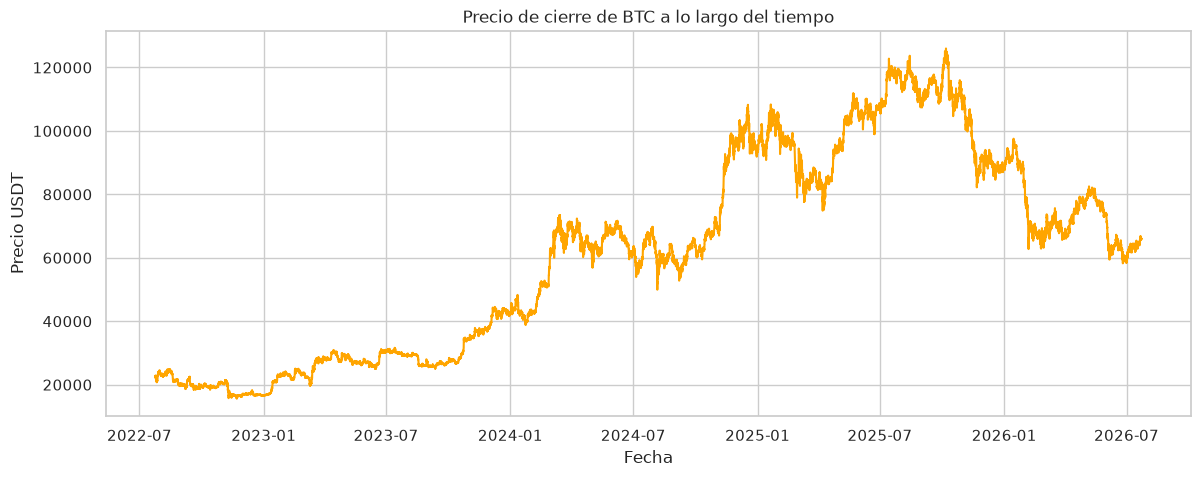

In [128]:
plt.figure(figsize=(14, 5))
plt.plot(btc["datetime"], btc["close"], color="orange")
plt.title("Precio de cierre de BTC a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Precio USDT")
plt.show()

### 4.7 Distribución del precio de cierre (histograma)

Un histograma muestra cuántas veces el precio estuvo en cada rango.
Nos ayuda a ver la forma de la distribución.

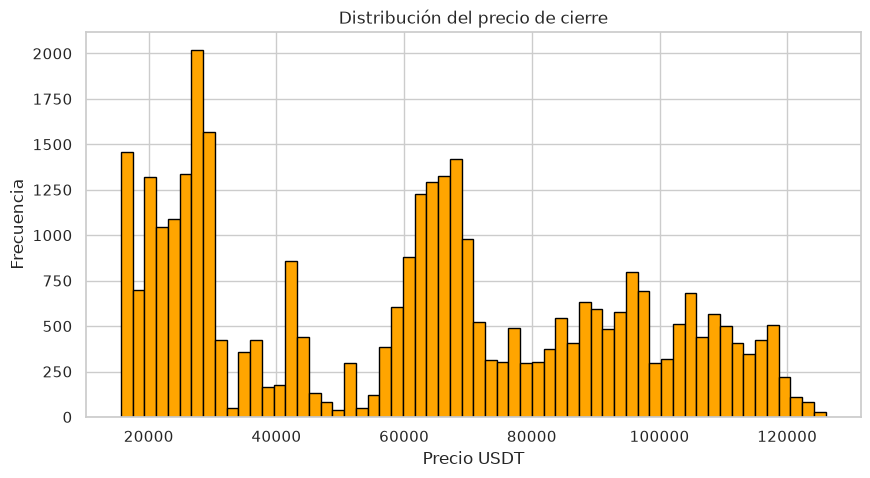

In [129]:
plt.figure(figsize=(10, 5))
plt.hist(btc["close"], bins=60, color="orange", edgecolor="black")
plt.title("Distribución del precio de cierre")
plt.xlabel("Precio USDT")
plt.ylabel("Frecuencia")
plt.show()

### 4.8 Distribución del volumen (histograma)

El volumen normalmente tiene una distribución muy sesgada — muchas horas
con volumen bajo y unas pocas horas con volumen enorme.

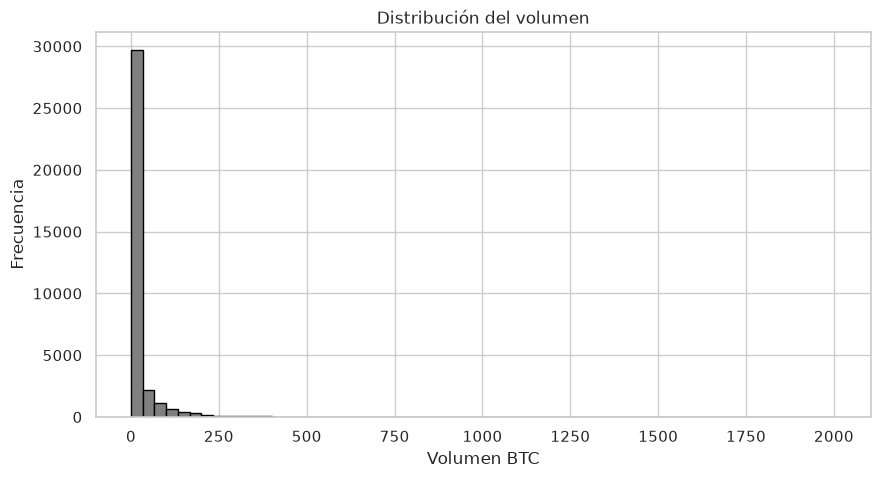

In [130]:
plt.figure(figsize=(10, 5))
plt.hist(btc["volume"], bins=60, color="gray", edgecolor="black")
plt.title("Distribución del volumen")
plt.xlabel("Volumen BTC")
plt.ylabel("Frecuencia")
plt.show()

### 4.9 Retornos logarítmicos

El precio en sí no es muy útil para modelar porque tiene tendencia (sube y baja
en periodos largos). Los **retornos** son mejores porque miden el cambio
porcentual entre una vela y la siguiente.

Fórmula del retorno logarítmico:

`retorno = log(precio_actual / precio_anterior)`

Los usamos porque son aditivos en el tiempo (matemáticamente se comportan mejor
que los retornos porcentuales).

In [131]:
# Calculamos el retorno logarítmico horario
btc["log_return"] = np.log(btc["close"] / btc["close"].shift(1))

# La primera fila tendrá NaN porque no hay vela anterior
btc[["datetime", "close", "log_return"]].head()

,datetime,close,log_return
0,2022-07-24 02:00:00,22475.01,NaN
1,2022-07-24 03:00:00,22329.94,-0.006476
2,2022-07-24 04:00:00,22394.78,0.002900
3,2022-07-24 05:00:00,22742.03,0.015387
4,2022-07-24 06:00:00,22674.03,-0.002995


### 4.10 Medidas estadísticas de los retornos

In [132]:
retornos = btc["log_return"].dropna()  # quitamos el primer NaN

print("--- Retornos logarítmicos ---")
print(f"  Media:            {retornos.mean():.6f}")
print(f"  Mediana:          {retornos.median():.6f}")
print(f"  Desv. estándar:   {retornos.std():.6f}")
print(f"  Mínimo:           {retornos.min():.6f}")
print(f"  Máximo:           {retornos.max():.6f}")
print(f"  Asimetría (skew): {retornos.skew():.4f}")
print(f"  Curtosis:         {retornos.kurt():.4f}")

--- Retornos logarítmicos ---
  Media:            0.000031
  Mediana:          0.000055
  Desv. estándar:   0.005012
  Mínimo:           -0.064474
  Máximo:           0.057294
  Asimetría (skew): -0.2358
  Curtosis:         13.9622


### 4.11 Distribución de los retornos

Comparamos el histograma con una distribución normal (curva) para ver si
los retornos siguen una campana o si tienen colas más pesadas.

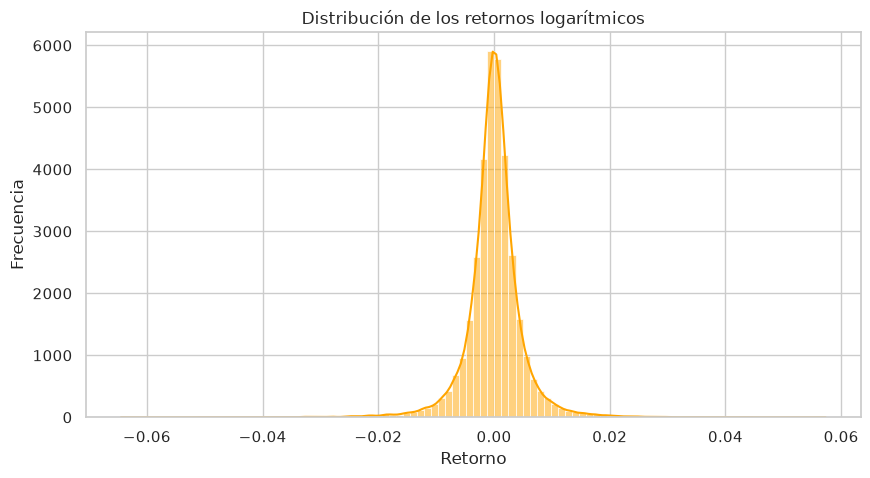

In [133]:
plt.figure(figsize=(10, 5))
sns.histplot(retornos, bins=100, kde=True, color="orange")
plt.title("Distribución de los retornos logarítmicos")
plt.xlabel("Retorno")
plt.ylabel("Frecuencia")
plt.show()

### 4.12 Contrastes de hipótesis

Vamos a aplicar dos contrastes de hipótesis siguiendo 4 pasos:

1. Definir la hipótesis (H₀ y H₁).
2. Elegir el nivel de significación α.
3. Verificar la hipótesis (calcular Z-score y p-valor).
4. Tomar decisión (aceptar o rechazar H₀).

Nivel de significación para ambos: **α = 0.05**.

### 4.13 Contraste 1 — Media de los retornos vs. cero

**Pregunta**: ¿los retornos horarios de BTC tienen una media distinta de cero?

**Hipótesis**:
- H₀: la media de los retornos = 0 (no hay tendencia sistemática).
- H₁: la media de los retornos ≠ 0.

**Test**: contraste para la media con Z-Test (tenemos muestra grande: ~35,000 observaciones).

**Fórmula del Z-score**:

`Z = (media_muestral - media_poblacional) / (desv_std / raíz(n))`

Donde asumimos media_poblacional = 0 (hipótesis nula).

**Por qué importa**: si la media de retornos fuera claramente positiva, con
solo comprar y esperar ya se ganaría dinero. Si es prácticamente cero,
necesitamos un modelo para encontrar señal en los patrones.

In [134]:
# --- Paso 1: definir hipótesis ---
# H0: media de retornos = 0
# H1: media de retornos != 0

# --- Paso 2: nivel de significación ---
alpha = 0.05

# --- Paso 3: verificar la hipótesis ---
media_poblacional = 0                # lo que dice H0
media_muestral = retornos.mean()     # lo que observamos
desv_std = retornos.std()
n = len(retornos)

# Calculamos el Z-score
z_score = (media_muestral - media_poblacional) / (desv_std / np.sqrt(n))

# Calculamos el p-valor (test bilateral porque H1 es "distinta de")
p_valor = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Media muestral: {media_muestral:.8f}")
print(f"Desv. estándar: {desv_std:.6f}")
print(f"Tamaño muestra: {n}")
print(f"Z-score: {z_score:.4f}")
print(f"p-valor: {p_valor:.6f}")

# --- Paso 4: decisión ---
if p_valor < alpha:
    print("\nDecisión: rechazamos H0 → la media es distinta de 0")
else:
    print("\nDecisión: no rechazamos H0 → la media podría ser 0")

Media muestral: 0.00003072
Desv. estándar: 0.005012
Tamaño muestra: 35032
Z-score: 1.1473
p-valor: 0.251273

Decisión: no rechazamos H0 → la media podría ser 0


### 4.14 Contraste 2 — Proporción de velas alcistas

**Pregunta**: ¿la proporción de velas alcistas (donde el precio sube) es
distinta del 50%?

**Hipótesis**:
- H₀: la proporción de velas alcistas = 0.5 (el mercado es simétrico).
- H₁: la proporción de velas alcistas ≠ 0.5.

**Test**: contraste para la proporción con Z-Test.

**Fórmula del Z-score**:

`Z = (proporción_muestral - proporción_poblacional) / raíz(p * (1-p) / n)`

**Por qué importa**: si la proporción es claramente >50%, tenemos un sesgo
alcista aprovechable. Si es 50%, la dirección es un problema realmente difícil
y el modelo de ML tiene que trabajar en los patrones, no en el promedio.

**Nota**: esta pregunta se conecta directo con nuestro **target** de ML: vamos
a predecir la dirección (sube/baja) de la próxima vela.

In [135]:
# Primero: creamos una columna que marca si la vela fue alcista o bajista
# 1 = alcista (close > open), 0 = bajista o neutral
btc["vela_alcista"] = (btc["close"] > btc["open"]).astype(int)

# --- Paso 1: definir hipótesis ---
# H0: proporción de velas alcistas = 0.5
# H1: proporción de velas alcistas != 0.5

# --- Paso 2: nivel de significación ---
alpha = 0.05

# --- Paso 3: verificar la hipótesis ---
proporcion_poblacional = 0.5                       # lo que dice H0
proporcion_muestral = btc["vela_alcista"].mean()   # lo que observamos
n = len(btc)

# Calculamos el Z-score (fórmula del curso, para proporciones)
z_score = (proporcion_muestral - proporcion_poblacional) / np.sqrt(
    (proporcion_poblacional * (1 - proporcion_poblacional)) / n
)

# Calculamos el p-valor (test bilateral)
p_valor = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Proporción muestral de velas alcistas: {proporcion_muestral:.4f}")
print(f"Tamaño muestra: {n}")
print(f"Z-score: {z_score:.4f}")
print(f"p-valor: {p_valor:.6f}")

# --- Paso 4: decisión ---
if p_valor < alpha:
    print("\nDecisión: rechazamos H0 → la proporción es distinta de 0.5")
else:
    print("\nDecisión: no rechazamos H0 → la proporción podría ser 0.5")

Proporción muestral de velas alcistas: 0.5034
Tamaño muestra: 35033
Z-score: 1.2555
p-valor: 0.209284

Decisión: no rechazamos H0 → la proporción podría ser 0.5


### 4.15 Conclusiones del análisis descriptivo

**Sobre los datos**:
- ~35,000 velas horarias de BTC/USDT, sin nulos.
- Rango temporal: ~4 años (bear 2022, recuperación 2023, bull run 2024-2025, ciclo actual).

**Sobre las distribuciones**:
- El precio muestra distintos regímenes (bear y bull markets).
- El volumen es fuertemente asimétrico, con picos extremos.
- Los retornos logarítmicos están centrados cerca de cero con colas pesadas.

**Sobre los contrastes de hipótesis**:

- **Contraste 1 (media de retornos):**
  Media muestral = 0.00003, p-valor = 0.2513.
  → No rechazamos H₀. La media horaria es estadísticamente cero.

- **Contraste 2 (proporción de velas alcistas):**
  Proporción muestral = 50.34%, p-valor = 0.2093.
  → No rechazamos H₀. Las velas están estadísticamente balanceadas.

**Conclusión clave para el proyecto**:

Ninguna medida descriptiva simple da señal aprovechable:
- La media horaria de retornos es prácticamente cero.
- La dirección está balanceada al 50/50.

Esto **justifica la necesidad de un modelo de Machine Learning**: si hay
señal en el mercado, no está en el promedio ni en el conteo — está en
patrones más complejos combinando indicadores técnicos. Ese es el trabajo
de las siguientes fases.

**Próximo paso**: **Paso 5 — EDA completo**. Exploraremos relaciones entre
variables, detectaremos anomalías, decidiremos qué features mantener, y
prepararemos el split train/test.

Detección de outliers en retornos

Un outlier de retorno es una vela donde el precio se movió mucho más de lo
normal. En cripto, estos movimientos pueden ser:

- Errores de datos (rarísimo con Binance).
- Eventos reales: flash crashes, noticias, liquidaciones masivas.

Como en trading los eventos extremos son reales, no vamos a eliminarlos,
solo los marcamos para que el modelo pueda aprender de ellos (o para poder
inspeccionarlos después).

Usamos la regla clásica: un valor es outlier si está a más de 3 desviaciones
estándar de la media.

In [136]:
#calculamos los límites de outlier para los retornos
media_ret = retornos.mean()
std_ret = retornos.std()

limite_superior = media_ret + 3 * std_ret
limite_inferior = media_ret - 3 * std_ret

print(f"Límite inferior: {limite_inferior:.4f} ({limite_inferior*100:.2f}%)")
print(f"Límite superior: {limite_superior:.4f} ({limite_superior*100:.2f}%)")

# Contamos cuántos hay
outliers_retornos = btc[(btc["log_return"] > limite_superior) | (btc["log_return"] < limite_inferior)]
print(f"\nOutliers de retorno detectados: {len(outliers_retornos)}")
print(f"Porcentaje del total: {len(outliers_retornos) / len(btc) * 100:.2f}%")

Límite inferior: -0.0150 (-1.50%)
Límite superior: 0.0151 (1.51%)

Outliers de retorno detectados: 682
Porcentaje del total: 1.95%


Visualizar los outliers en el tiempo

Vamos a ver cuándo ocurrieron los movimientos extremos. Esperamos que
coincidan con eventos conocidos: colapso de FTX (nov 2022), colapso de LUNA
(may 2022), aprobación del ETF (ene 2024), etc.

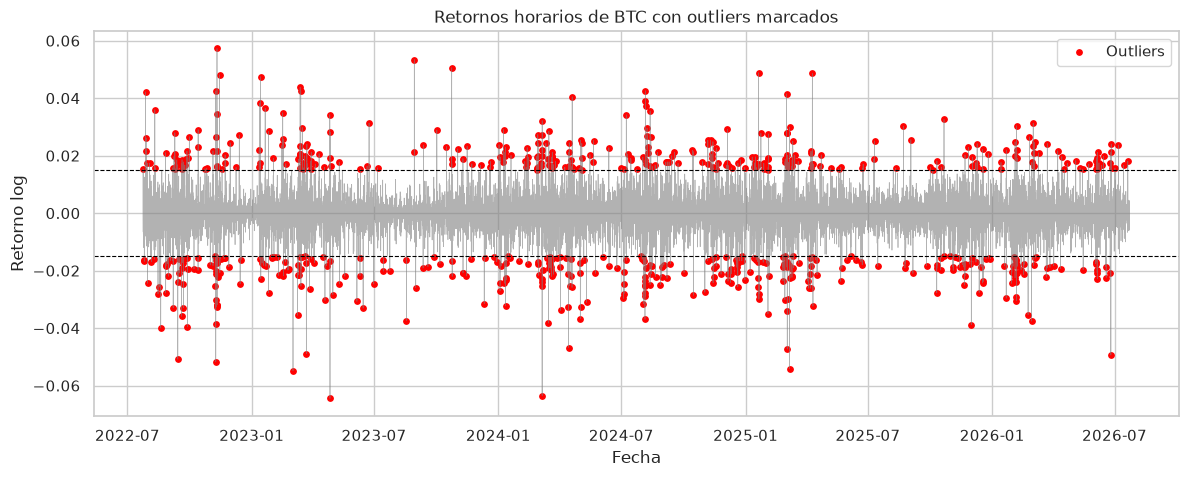

In [137]:
plt.figure(figsize=(14, 5))
plt.plot(btc["datetime"], btc["log_return"], color="gray", linewidth=0.5, alpha=0.6)
plt.scatter(outliers_retornos["datetime"], outliers_retornos["log_return"],
            color="red", s=15, label="Outliers")
plt.axhline(limite_superior, color="black", linestyle="--", linewidth=0.8)
plt.axhline(limite_inferior, color="black", linestyle="--", linewidth=0.8)
plt.title("Retornos horarios de BTC con outliers marcados")
plt.xlabel("Fecha")
plt.ylabel("Retorno log")
plt.legend()
plt.show()

Marcamos los outliers en el dataset

En lugar de eliminarlos, creamos una columna binaria `es_outlier` que
podrá servir como feature adicional para el modelo. Esta información
puede ser útil: momentos de alta volatilidad se comportan distinto.

In [138]:
btc["es_outlier"] = ((btc["log_return"] > limite_superior) |
                     (btc["log_return"] < limite_inferior)).astype(int)

print(f"Outliers marcados: {btc['es_outlier'].sum()}")
print(f"Velas normales: {(btc['es_outlier'] == 0).sum()}")

Outliers marcados: 682
Velas normales: 34351


Feature Engineering

Indicadores técnicos

Los precios brutos (open, high, low, close) no son buenos features tal cual —
tienen tendencia y su valor absoluto cambia a lo largo del tiempo (BTC a $20k
en 2022 vs $70k en 2024). Necesitamos convertirlos en **indicadores técnicos**
que capturen información relativa y estable en el tiempo.

Vamos a crear features de 4 categorías:

1. **Retornos en distintas ventanas** — cuánto se ha movido el precio en las
   últimas N horas.
2. **Medias móviles y distancia al precio** — tendencia y cuán "lejos" está
   el precio de esa tendencia.
3. **Volatilidad** — qué tan "salvaje" ha estado el mercado.
4. **Indicadores clásicos de trading** — RSI y MACD.

Regla de oro: **todo se calcula con datos PASADOS**. Nunca miramos al futuro
para calcular una feature, o estaríamos haciendo trampa (data leakage).

Retornos en distintas ventanas

Un modelo puede aprender que "si el precio subió 3% en las últimas 24 horas,
suele venir una corrección". Para capturar eso necesitamos features que
midan el movimiento en distintas ventanas de tiempo.

In [139]:
#retornos porcentuales en distintas ventanas de tiempo (en horas)
btc["return_1h"] = btc["close"].pct_change(1)
btc["return_3h"] = btc["close"].pct_change(3)
btc["return_6h"] = btc["close"].pct_change(6)
btc["return_12h"] = btc["close"].pct_change(12)
btc["return_24h"] = btc["close"].pct_change(24)

btc[["datetime", "close", "return_1h", "return_6h", "return_24h"]].tail(10)

,datetime,close,return_1h,return_6h,return_24h
35023,2026-07-22 16:00:00,66219.08,0.003017,0.002013,-0.005047
35024,2026-07-22 17:00:00,66055.27,-0.002474,0.000334,-0.002130
35025,2026-07-22 18:00:00,65894.00,-0.002441,0.003661,-0.006163
35026,2026-07-22 19:00:00,65928.75,0.000527,-0.000085,-0.007513
35027,2026-07-22 20:00:00,65926.26,-0.000038,0.002989,-0.007159
35028,2026-07-22 21:00:00,66046.89,0.001830,0.000409,-0.004722
35029,2026-07-22 22:00:00,66044.37,-0.000038,-0.002638,-0.003922
35030,2026-07-22 23:00:00,66086.59,0.000639,0.000474,-0.007111
35031,2026-07-23 00:00:00,66063.13,-0.000355,0.002567,-0.008922
35032,2026-07-23 01:00:00,65934.40,-0.001949,0.000086,-0.006913


Medias móviles y distancia al precio

Una media móvil de N horas es el promedio del precio de las últimas N horas.
Nos dice cuál es la "tendencia" reciente.

La **distancia al precio** (`(precio - media) / media`) es aún más útil porque
te dice si el precio está por encima o por debajo de su tendencia, en términos
porcentuales.

In [140]:
#medias móviles simples (SMA) de 6, 12, 24 y 72 horas
btc["sma_6"] = btc["close"].rolling(window=6).mean()
btc["sma_12"] = btc["close"].rolling(window=12).mean()
btc["sma_24"] = btc["close"].rolling(window=24).mean()
btc["sma_72"] = btc["close"].rolling(window=72).mean()

#distancia porcentual del precio a cada media móvil
btc["dist_sma_6"] = (btc["close"] - btc["sma_6"]) / btc["sma_6"]
btc["dist_sma_12"] = (btc["close"] - btc["sma_12"]) / btc["sma_12"]
btc["dist_sma_24"] = (btc["close"] - btc["sma_24"]) / btc["sma_24"]
btc["dist_sma_72"] = (btc["close"] - btc["sma_72"]) / btc["sma_72"]

btc[["datetime", "close", "sma_24", "dist_sma_24"]].tail(5)

,datetime,close,sma_24,dist_sma_24
35028,2026-07-22 21:00:00,66046.89,66084.572083,-0.000570
35029,2026-07-22 22:00:00,66044.37,66073.737917,-0.000444
35030,2026-07-22 23:00:00,66086.59,66054.015833,0.000493
35031,2026-07-23 00:00:00,66063.13,66029.235000,0.000513
35032,2026-07-23 01:00:00,65934.40,66010.110833,-0.001147


Visualizamos las medias móviles

Graficamos el precio con dos de las medias móviles. Es la típica gráfica
de análisis técnico.

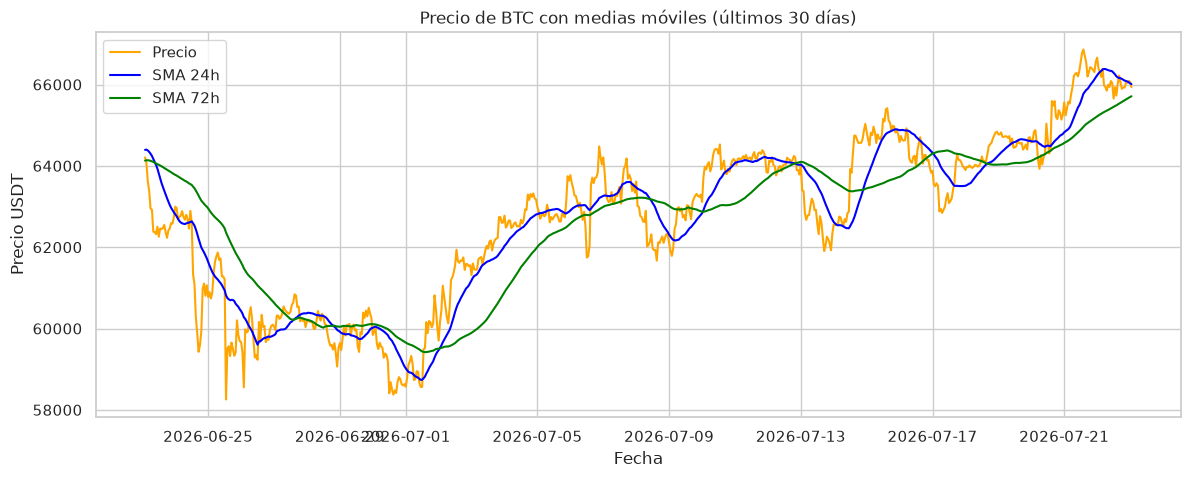

In [141]:
#tomamos solo los últimos 30 días para que se vea bien la gráfica
ultimos_30_dias = btc.tail(24 * 30)

plt.figure(figsize=(14, 5))
plt.plot(ultimos_30_dias["datetime"], ultimos_30_dias["close"], label="Precio", color="orange")
plt.plot(ultimos_30_dias["datetime"], ultimos_30_dias["sma_24"], label="SMA 24h", color="blue")
plt.plot(ultimos_30_dias["datetime"], ultimos_30_dias["sma_72"], label="SMA 72h", color="green")
plt.title("Precio de BTC con medias móviles (últimos 30 días)")
plt.xlabel("Fecha")
plt.ylabel("Precio USDT")
plt.legend()
plt.show()

Volatilidad

La volatilidad es la desviación estándar de los retornos en una ventana.
Un mercado con alta volatilidad se mueve mucho; con baja volatilidad, poco.

Es una señal importante: los patrones que funcionan en baja volatilidad
suelen fallar en alta volatilidad.

In [142]:
#volatilidad = desviación estándar de los retornos en las últimas N horas
btc["volatilidad_6h"] = btc["log_return"].rolling(window=6).std()
btc["volatilidad_24h"] = btc["log_return"].rolling(window=24).std()

btc[["datetime", "close", "log_return", "volatilidad_24h"]].tail(5)

,datetime,close,log_return,volatilidad_24h
35028,2026-07-22 21:00:00,66046.89,0.001828,0.002968
35029,2026-07-22 22:00:00,66044.37,-0.000038,0.002965
35030,2026-07-22 23:00:00,66086.59,0.000639,0.002846
35031,2026-07-23 00:00:00,66063.13,-0.000355,0.002821
35032,2026-07-23 01:00:00,65934.40,-0.001950,0.002738


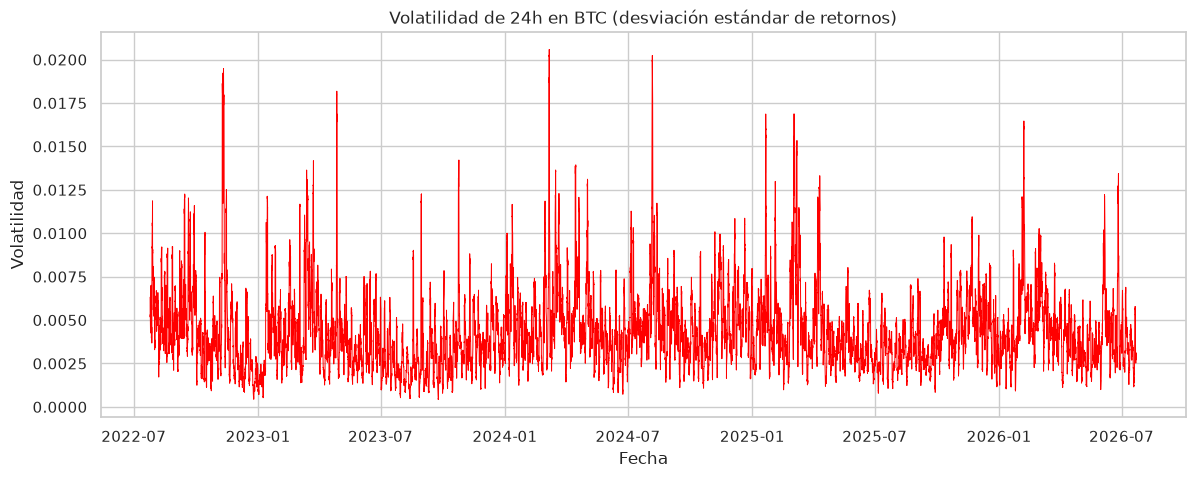

In [143]:
#grafica de la volatilidad de 24h para ver los periodos de estrés
plt.figure(figsize=(14, 5))
plt.plot(btc["datetime"], btc["volatilidad_24h"], color="red", linewidth=0.7)
plt.title("Volatilidad de 24h en BTC (desviación estándar de retornos)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.show()

RSI (Relative Strength Index)

El RSI es el indicador más famoso del análisis técnico. Mide la fuerza
relativa de las subidas vs las bajadas en las últimas N velas
(típicamente 14).

- **RSI = 100** → todas las velas subieron (sobrecomprado, probable corrección).
- **RSI = 0** → todas bajaron (sobrevendido, probable rebote).
- **RSI ~ 50** → equilibrio.

La lectura clásica de trader:
- **RSI > 70** → sobrecomprado.
- **RSI < 30** → sobrevendido.

Fórmula:
- `RS = promedio_ganancias / promedio_pérdidas`
- `RSI = 100 - (100 / (1 + RS))`

In [144]:
#diferencia entre el precio actual y el anterior
delta = btc["close"].diff()

# Separamos las ganancias (positivas) y las pérdidas (negativas)
ganancias = delta.clip(lower=0)              # todo lo que sea negativo se vuelve 0
perdidas = -delta.clip(upper=0)              # todo lo que sea positivo se vuelve 0

# Promedio móvil de 14 periodos
promedio_ganancias = ganancias.rolling(window=14).mean()
promedio_perdidas = perdidas.rolling(window=14).mean()

# RS y RSI
rs = promedio_ganancias / promedio_perdidas
btc["rsi_14"] = 100 - (100 / (1 + rs))

btc[["datetime", "close", "rsi_14"]].tail(10)

,datetime,close,rsi_14
35023,2026-07-22 16:00:00,66219.08,48.246536
35024,2026-07-22 17:00:00,66055.27,47.483183
35025,2026-07-22 18:00:00,65894.00,40.550626
35026,2026-07-22 19:00:00,65928.75,48.839952
35027,2026-07-22 20:00:00,65926.26,49.714855
35028,2026-07-22 21:00:00,66046.89,54.458577
35029,2026-07-22 22:00:00,66044.37,51.259268
35030,2026-07-22 23:00:00,66086.59,53.495530
35031,2026-07-23 00:00:00,66063.13,49.414709
35032,2026-07-23 01:00:00,65934.40,47.570677


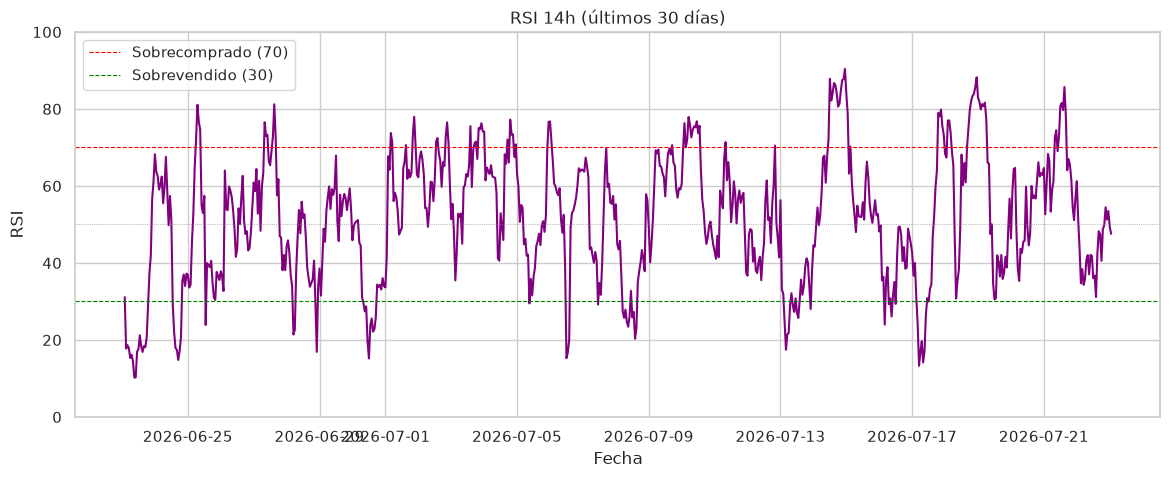

In [145]:
#ultimos_30_dias para que incluya las nuevas columnas (RSI, etc.)
ultimos_30_dias = btc.tail(24 * 30)

# Graficamos el RSI de los últimos 30 días
plt.figure(figsize=(14, 5))
plt.plot(ultimos_30_dias["datetime"], ultimos_30_dias["rsi_14"], color="purple")
plt.axhline(70, color="red", linestyle="--", linewidth=0.8, label="Sobrecomprado (70)")
plt.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Sobrevendido (30)")
plt.axhline(50, color="gray", linestyle=":", linewidth=0.5)
plt.title("RSI 14h (últimos 30 días)")
plt.xlabel("Fecha")
plt.ylabel("RSI")
plt.ylim(0, 100)
plt.legend()
plt.show()

Bandas de Bollinger

Las bandas de Bollinger son 3 líneas:
- **Banda central**: media móvil de 20 periodos.
- **Banda superior**: media + 2 desviaciones estándar.
- **Banda inferior**: media − 2 desviaciones estándar.

Cuando el precio "toca" la banda superior, suele estar sobrecomprado;
cuando toca la inferior, sobrevendido.

Como feature usamos **%B**, que dice dónde está el precio dentro de las bandas:
- `%B = 0` → precio en la banda inferior.
- `%B = 1` → precio en la banda superior.
- `%B = 0.5` → precio en la media.

In [146]:
#media móvil y desviación estándar de 20 periodos
sma_20 = btc["close"].rolling(window=20).mean()
std_20 = btc["close"].rolling(window=20).std()

#bandas superior e inferior
banda_superior = sma_20 + 2 * std_20
banda_inferior = sma_20 - 2 * std_20

#%B: dónde está el precio dentro de las bandas
btc["bollinger_pct"] = (btc["close"] - banda_inferior) / (banda_superior - banda_inferior)

btc[["datetime", "close", "bollinger_pct"]].tail(5)

,datetime,close,bollinger_pct
35028,2026-07-22 21:00:00,66046.89,0.558270
35029,2026-07-22 22:00:00,66044.37,0.580228
35030,2026-07-22 23:00:00,66086.59,0.658135
35031,2026-07-23 00:00:00,66063.13,0.680528
35032,2026-07-23 01:00:00,65934.40,0.432676


MACD (Moving Average Convergence Divergence)

El MACD es otro indicador clásico. Se calcula con la diferencia entre dos
medias móviles exponenciales (EMAs) — una rápida (12 periodos) y una lenta
(26 periodos).

- **MACD > 0** → la tendencia corta es más alcista que la larga.
- **MACD < 0** → la tendencia corta es más bajista que la larga.

También usamos la **señal MACD**: EMA de 9 periodos del propio MACD.
Cuando el MACD cruza por encima de su señal, se considera bullish.

In [147]:
#EMA de 12 y 26 periodos (exponential moving average)
ema_12 = btc["close"].ewm(span=12, adjust=False).mean()
ema_26 = btc["close"].ewm(span=26, adjust=False).mean()

# MACD y su señal
btc["macd"] = ema_12 - ema_26
btc["macd_signal"] = btc["macd"].ewm(span=9, adjust=False).mean()

btc[["datetime", "close", "macd", "macd_signal"]].tail(5)

,datetime,close,macd,macd_signal
35028,2026-07-22 21:00:00,66046.89,-29.551253,-21.252805
35029,2026-07-22 22:00:00,66044.37,-23.240879,-21.650420
35030,2026-07-22 23:00:00,66086.59,-14.664024,-20.253141
35031,2026-07-23 00:00:00,66063.13,-9.648607,-18.132234
35032,2026-07-23 01:00:00,65934.40,-15.878254,-17.681438


Features de la vela (candlestick)

Cada vela tiene una forma que también aporta información:
- **Cuerpo** (`body`): tamaño del movimiento entre apertura y cierre.
- **Rango** (`range`): distancia entre máximo y mínimo.
- **Mecha superior** (`upper_wick`): cuánto rechazó el mercado desde arriba.
- **Mecha inferior** (`lower_wick`): cuánto rechazó desde abajo.

Estos features son la esencia del análisis de "velas japonesas" (candlestick patterns)

In [148]:
#todas las features relativizadas al precio de apertura para que sean comparables en el tiempo
btc["cuerpo_vela"] = (btc["close"] - btc["open"]) / btc["open"]
btc["rango_vela"] = (btc["high"] - btc["low"]) / btc["open"]
btc["mecha_superior"] = (btc["high"] - btc[["open", "close"]].max(axis=1)) / btc["open"]
btc["mecha_inferior"] = (btc[["open", "close"]].min(axis=1) - btc["low"]) / btc["open"]

btc[["datetime", "cuerpo_vela", "rango_vela", "mecha_superior", "mecha_inferior"]].tail(5)

,datetime,cuerpo_vela,rango_vela,mecha_superior,mecha_inferior
35028,2026-07-22 21:00:00,0.001879,0.003317,0.001292,0.000146
35029,2026-07-22 22:00:00,-0.000117,0.001705,0.000000,0.001588
35030,2026-07-22 23:00:00,0.000592,0.003820,0.000653,0.002576
35031,2026-07-23 00:00:00,-0.000420,0.003662,0.003124,0.000117
35032,2026-07-23 01:00:00,-0.001826,0.004231,0.001998,0.000407


Features de tiempo (estacionalidad)

Aunque el mercado cripto es 24/7, hay patrones por hora del día
(sesiones de Asia, Europa, EEUU) y por día de la semana. Extraemos
esas dos features del timestamp.

In [149]:
btc["hora"] = btc["datetime"].dt.hour
btc["dia_semana"] = btc["datetime"].dt.dayofweek  # 0=Lunes, 6=Domingo

btc[["datetime", "hora", "dia_semana"]].tail(5)

,datetime,hora,dia_semana
35028,2026-07-22 21:00:00,21,2
35029,2026-07-22 22:00:00,22,2
35030,2026-07-22 23:00:00,23,2
35031,2026-07-23 00:00:00,0,3
35032,2026-07-23 01:00:00,1,3


Resumen de features creadas

Vamos a ver todas las columnas que hemos añadido al dataset.

In [150]:
print(f"Total de columnas en el dataset: {btc.shape[1]}")
print(f"Total de filas: {btc.shape[0]}")
print(f"\nColumnas disponibles: {btc.columns}")

Total de columnas en el dataset: 42
Total de filas: 35033

Columnas disponibles: Index(['open_time', 'close_time', 'open', 'high', 'low', 'close', 'volume',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume',
       'taker_buy_quote_volume', 'symbol', 'interval', 'datetime',
       'log_return', 'vela_alcista', 'es_outlier', 'return_1h', 'return_3h',
       'return_6h', 'return_12h', 'return_24h', 'sma_6', 'sma_12', 'sma_24',
       'sma_72', 'dist_sma_6', 'dist_sma_12', 'dist_sma_24', 'dist_sma_72',
       'volatilidad_6h', 'volatilidad_24h', 'rsi_14', 'bollinger_pct', 'macd',
       'macd_signal', 'cuerpo_vela', 'rango_vela', 'mecha_superior',
       'mecha_inferior', 'hora', 'dia_semana'],
      dtype='str')


Creación de la variable objetivo (target)

Nuestro problema es **clasificación binaria supervisada**: queremos predecir
la dirección del precio en la **próxima** vela horaria.

- `target = 1` → el precio SUBE en la próxima vela (close_futuro > close_actual).
- `target = 0` → el precio BAJA o queda igual.

Esta es la única columna que "mira al futuro", pero está bien porque es
justamente lo que queremos predecir. En la práctica, para entrenar necesitamos
saber qué pasó después (target); al desplegar el modelo, no lo sabremos y
lo tendrá que predecir.

**Regla de oro**: la variable objetivo se construye con `.shift(-1)` para
tomar el valor de la SIGUIENTE fila (el futuro respecto a la fila actual).

In [151]:
# El close de la próxima vela (horizonte 1h)
btc["close_futuro"] = btc["close"].shift(-1)

# target: 1 si sube, 0 si no
btc["target"] = (btc["close_futuro"] > btc["close"]).astype(int)

# Mostramos las últimas filas para verificar
btc[["datetime", "close", "close_futuro", "target"]].tail(10)

,datetime,close,close_futuro,target
35023,2026-07-22 16:00:00,66219.08,66055.27,0
35024,2026-07-22 17:00:00,66055.27,65894.00,0
35025,2026-07-22 18:00:00,65894.00,65928.75,1
35026,2026-07-22 19:00:00,65928.75,65926.26,0
35027,2026-07-22 20:00:00,65926.26,66046.89,1
35028,2026-07-22 21:00:00,66046.89,66044.37,0
35029,2026-07-22 22:00:00,66044.37,66086.59,1
35030,2026-07-22 23:00:00,66086.59,66063.13,0
35031,2026-07-23 00:00:00,66063.13,65934.40,0
35032,2026-07-23 01:00:00,65934.40,NaN,0


Balance del target

¿Cuántas velas son alcistas vs bajistas? Ya lo comprobamos en el contraste
de hipótesis 2 (~50.34%), pero aquí lo confirmamos con las filas del dataset.

Un balance cercano a 50/50 significa que **accuracy sola no es suficiente**
para evaluar el modelo (necesitaremos también precision, recall, F1, ROC-AUC).

In [152]:
print("Distribución del target:")
print(btc["target"].value_counts())
print("\nProporción:")
print(btc["target"].value_counts(normalize=True))

Distribución del target:
target
1    17818
0    17215
Name: count, dtype: int64

Proporción:
target
1    0.508606
0    0.491394
Name: proportion, dtype: float64


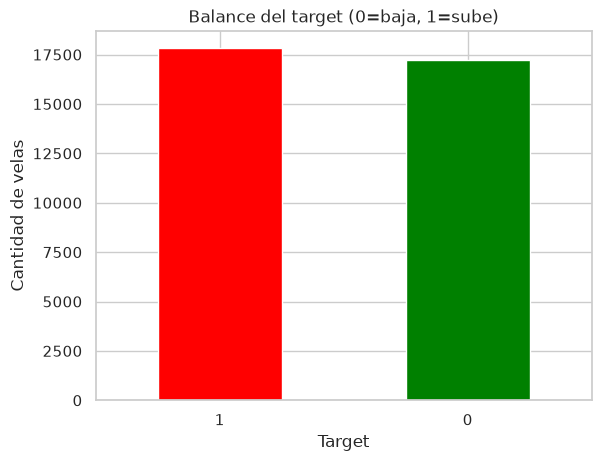

In [153]:
btc["target"].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Balance del target (0=baja, 1=sube)")
plt.xlabel("Target")
plt.ylabel("Cantidad de velas")
plt.xticks(rotation=0)
plt.show()

In [154]:
#columnas que NO son features
no_features = [
    "datetime", "open_time", "close_time", "interval", "symbol",
    "open", "high", "low", "close",
    "sma_6", "sma_12", "sma_24", "sma_72",
    "close_futuro", "vela_alcista", "target"
]

#recorremos todas las columnas y nos quedamos con las que NO están en no_features
features = []
for columna in btc.columns:
    if columna not in no_features:
        features.append(columna)

print(f"Total de features candidatas: {len(features)}")
print()
print("Lista de features:")
for f in features:
    print(f"  - {f}")

Total de features candidatas: 28

Lista de features:
  - volume
  - quote_asset_volume
  - number_of_trades
  - taker_buy_base_volume
  - taker_buy_quote_volume
  - log_return
  - es_outlier
  - return_1h
  - return_3h
  - return_6h
  - return_12h
  - return_24h
  - dist_sma_6
  - dist_sma_12
  - dist_sma_24
  - dist_sma_72
  - volatilidad_6h
  - volatilidad_24h
  - rsi_14
  - bollinger_pct
  - macd
  - macd_signal
  - cuerpo_vela
  - rango_vela
  - mecha_superior
  - mecha_inferior
  - hora
  - dia_semana


In [155]:
#seleccion las features + el target
df_para_correlacion = btc[features + ["target"]]

#calculo de la matriz de correlación y nos quedamos con la columna 'target'
correlaciones = df_para_correlacion.corr()["target"]

#eliminamos la correlación del target consigo mismo (siempre es 1)
correlaciones = correlaciones.drop("target")

#creamos una columna con el valor absoluto para ordenar
correlaciones_df = pd.DataFrame({
    "correlacion": correlaciones,
    "correlacion_abs": correlaciones.abs()
})

#ordenamos por el valor absoluto (más importantes primero)
correlaciones_df = correlaciones_df.sort_values("correlacion_abs", ascending=False)

print("Correlación de cada feature con el target:")
print(correlaciones_df["correlacion"])

Correlación de cada feature con el target:
cuerpo_vela              -0.063575
dist_sma_6               -0.062664
log_return               -0.062595
return_1h                -0.062551
bollinger_pct            -0.061410
return_3h                -0.056174
dist_sma_12              -0.052968
return_6h                -0.048120
dist_sma_24              -0.042615
rsi_14                   -0.042231
return_24h               -0.036696
return_12h               -0.034296
dist_sma_72              -0.025887
mecha_inferior           -0.025026
macd                     -0.021240
macd_signal              -0.014207
volatilidad_6h            0.010580
dia_semana                0.008447
mecha_superior            0.007731
rango_vela                0.006981
hora                      0.006652
volatilidad_24h           0.005791
es_outlier                0.004187
taker_buy_quote_volume   -0.002085
number_of_trades         -0.001816
quote_asset_volume        0.000848
volume                    0.000845
taker_buy_ba

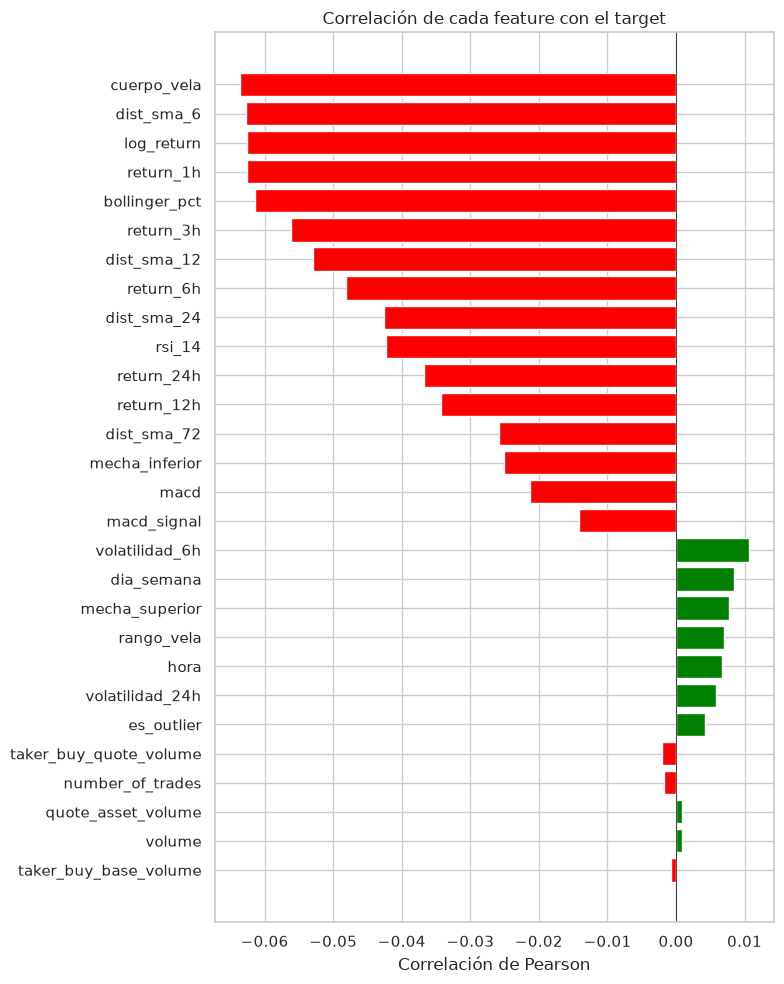

In [156]:
valores = correlaciones_df["correlacion"]

#colores según el signo: verde para positivas, rojo para negativas
colores = []
for valor in valores:
    if valor < 0:
        colores.append("red")
    else:
        colores.append("green")

# Graficamos
plt.figure(figsize=(8, 10))
plt.barh(valores.index, valores.values, color=colores)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Correlación de cada feature con el target")
plt.xlabel("Correlación de Pearson")
plt.gca().invert_yaxis()  # las más importantes arriba
plt.tight_layout()
plt.show()

Correlación entre features (detectar redundancia)

Dos features muy correlacionadas entre sí dicen básicamente lo mismo.
Ejemplo típico: `return_1h` y `log_return` son casi idénticas.
Meter las dos no aporta información nueva al modelo y puede confundirlo.

Regla práctica: si dos features tienen correlación absoluta > 0.9, nos
quedamos con una sola.

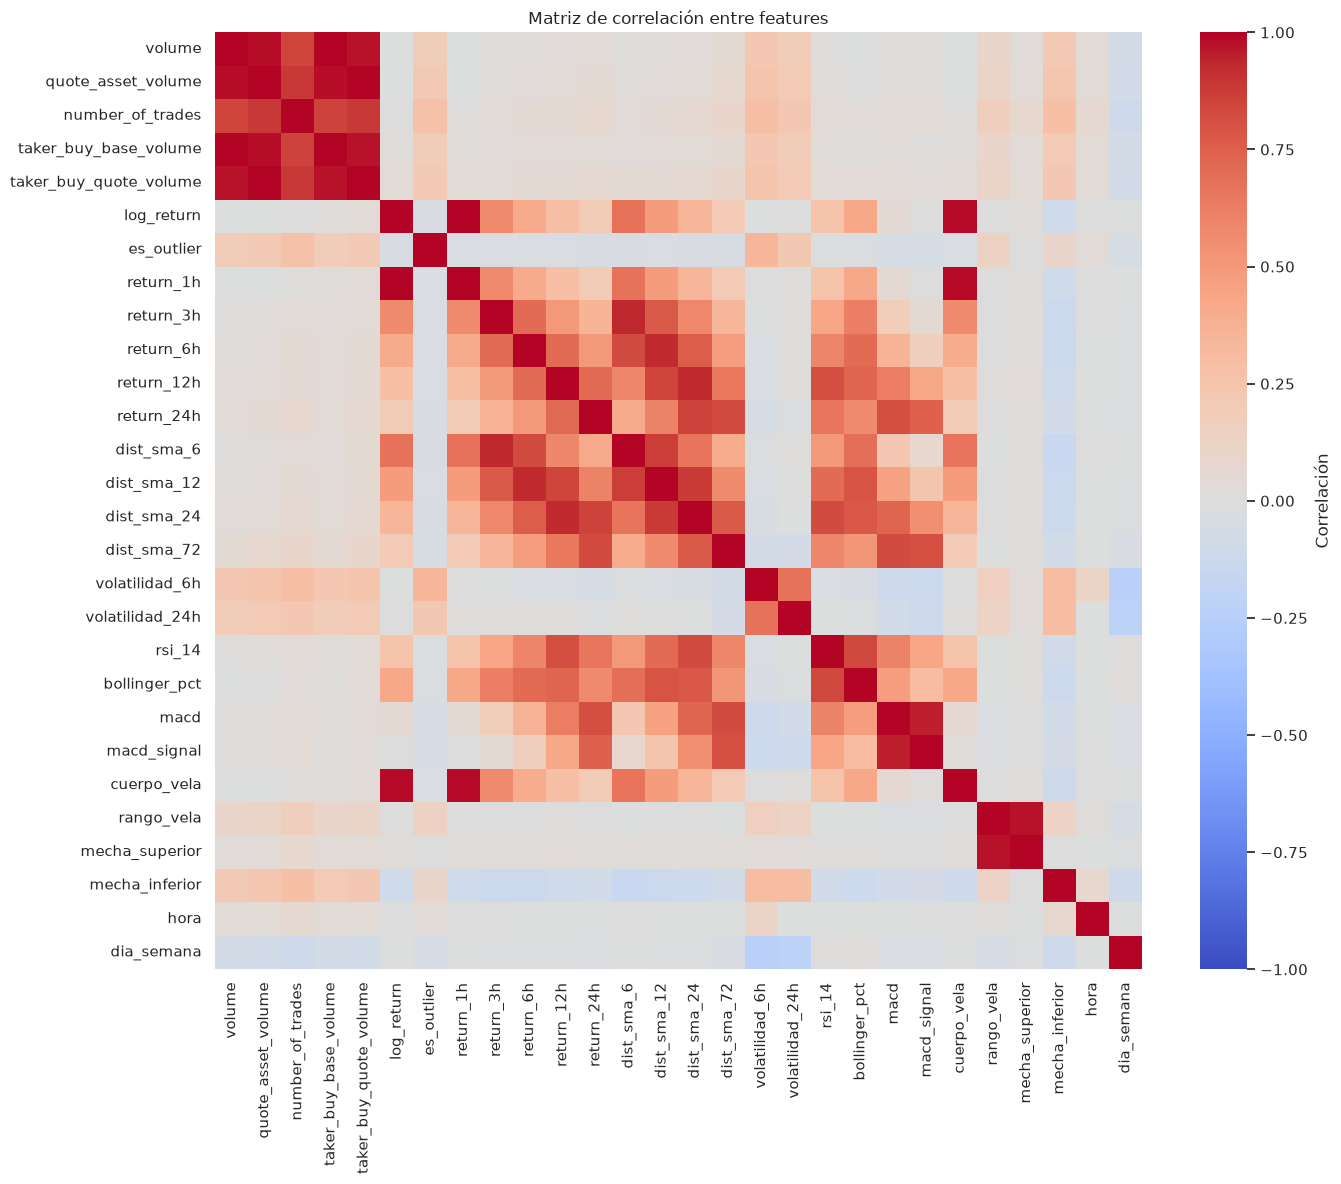

In [157]:
matriz_corr = btc[features].corr()

#grafica con seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(matriz_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, cbar_kws={"label": "Correlación"})
plt.title("Matriz de correlación entre features")
plt.tight_layout()
plt.show()

Detectar pares muy correlacionados

In [158]:
pares_redundantes = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feature_1 = features[i]
        feature_2 = features[j]
        correlacion = matriz_corr.loc[feature_1, feature_2]

        if abs(correlacion) > 0.9:
            pares_redundantes.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlacion": correlacion
            })

#pares encontrados
pares_df = pd.DataFrame(pares_redundantes)
pares_df = pares_df.sort_values("correlacion", key=abs, ascending=False)
print(f"Pares con correlación > 0.9: {len(pares_df)}")
pares_df

Pares con correlación > 0.9: 14


,feature_1,feature_2,correlacion
6,log_return,return_1h,0.999950
1,volume,taker_buy_base_volume,0.997142
4,quote_asset_volume,taker_buy_quote_volume,0.993642
8,return_1h,cuerpo_vela,0.985367
7,log_return,cuerpo_vela,0.985339
0,volume,quote_asset_volume,0.978571
3,quote_asset_volume,taker_buy_base_volume,0.976972
5,taker_buy_base_volume,taker_buy_quote_volume,0.976358
13,rango_vela,mecha_superior,0.975954
2,volume,taker_buy_quote_volume,0.970752


Selección final de features

Basándonos en el análisis anterior, eliminamos las features redundantes:

- **Eliminamos** `log_return` y `cuerpo_vela` → nos quedamos con `return_1h`.
- **Eliminamos** `quote_asset_volume`, `taker_buy_base_volume`,
  `taker_buy_quote_volume`, `number_of_trades` → nos quedamos con `volume`.
- **Eliminamos** `mecha_superior` → nos quedamos con `rango_vela`.
- **Eliminamos** `macd_signal` → nos quedamos con `macd`.
- **Eliminamos** `return_3h`, `return_6h`, `return_12h` → nos quedamos con
  las `dist_sma` que son más estacionarias.

También eliminamos `return_24h` (redundante con `dist_sma_24`).

In [159]:
features_finales = [
    "volume",           # volumen (representante del grupo de volumen)
    "es_outlier",       # marca si hubo movimiento extremo
    "return_1h",        # retorno de la última vela
    "dist_sma_6",       # distancia a media móvil de 6h
    "dist_sma_12",      # distancia a media móvil de 12h
    "dist_sma_24",      # distancia a media móvil de 24h
    "dist_sma_72",      # distancia a media móvil de 72h
    "volatilidad_6h",   # volatilidad corta
    "volatilidad_24h",  # volatilidad más larga
    "rsi_14",           # RSI clásico
    "bollinger_pct",    # posición dentro de las bandas de Bollinger
    "macd",             # MACD
    "rango_vela",       # tamaño total de la vela
    "mecha_inferior",   # mecha inferior
    "hora",             # hora del día
    "dia_semana",       # día de la semana
]

print(f"Features finales: {len(features_finales)}")
for f in features_finales:
    print(f"  - {f}")

Features finales: 16
  - volume
  - es_outlier
  - return_1h
  - dist_sma_6
  - dist_sma_12
  - dist_sma_24
  - dist_sma_72
  - volatilidad_6h
  - volatilidad_24h
  - rsi_14
  - bollinger_pct
  - macd
  - rango_vela
  - mecha_inferior
  - hora
  - dia_semana


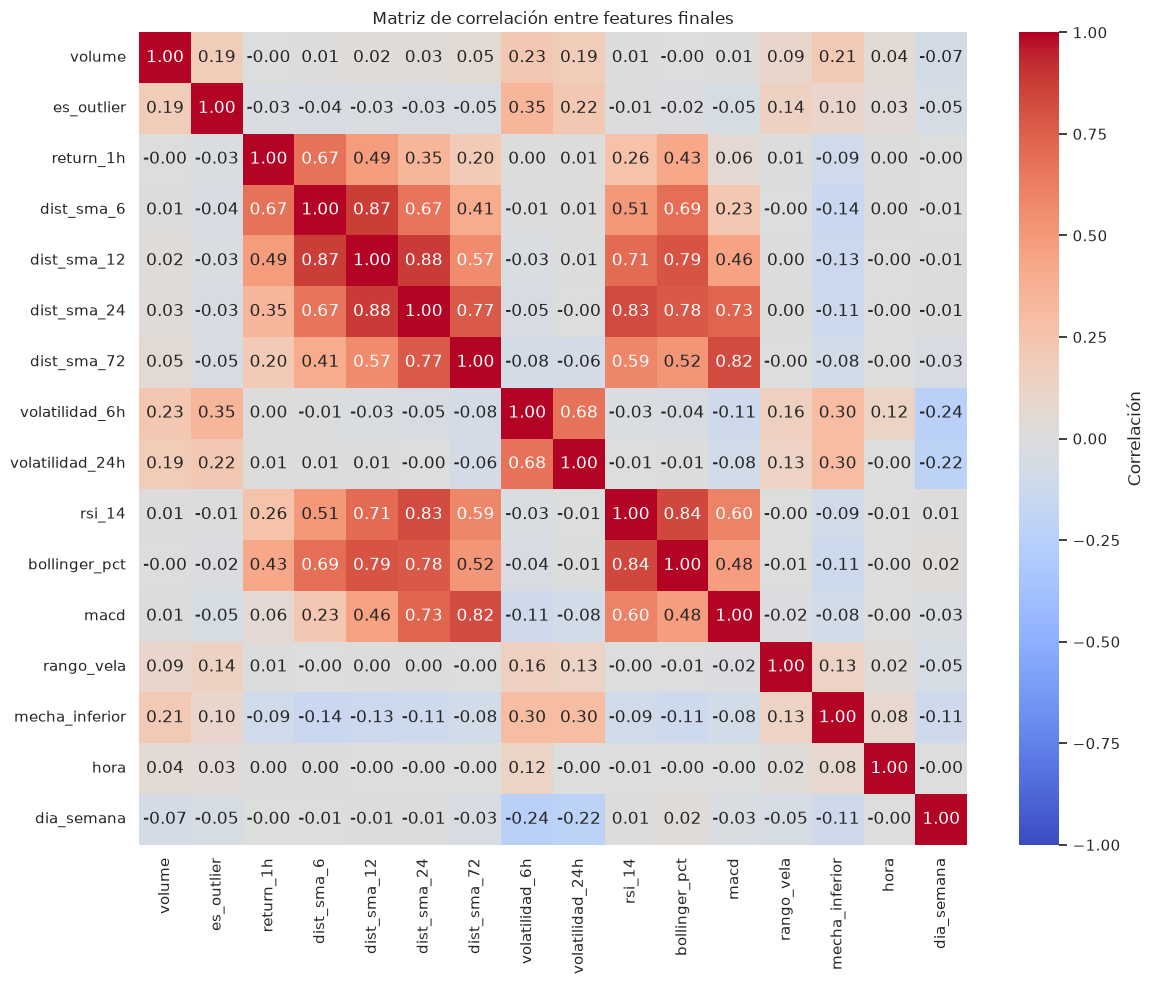

In [160]:
matriz_corr_final = btc[features_finales].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr_final, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", cbar_kws={"label": "Correlación"})
plt.title("Matriz de correlación entre features finales")
plt.tight_layout()
plt.show()

Limpieza final del dataset

In [161]:
print(f"Filas antes de limpiar: {len(btc)}")
print(f"NaN por columna (solo features + target):")
print(btc[features_finales + ["target"]].isnull().sum())

Filas antes de limpiar: 35033
NaN por columna (solo features + target):
volume              0
es_outlier          0
return_1h           1
dist_sma_6          5
dist_sma_12        11
dist_sma_24        23
dist_sma_72        71
volatilidad_6h      6
volatilidad_24h    24
rsi_14             14
bollinger_pct      19
macd                0
rango_vela          0
mecha_inferior      0
hora                0
dia_semana          0
target              0
dtype: int64


In [162]:
# Nos quedamos solo con las columnas que nos interesan + datetime para el split
df = btc[["datetime"] + features_finales + ["target"]].copy()

# Eliminamos filas con NaN
df = df.dropna()

# Reseteamos el índice
df = df.reset_index(drop=True)

print(f"Filas después de limpiar: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print("\nPrimeras filas:")
df.head()

Filas después de limpiar: 34962
Columnas: 18

Primeras filas:


,datetime,volume,es_outlier,return_1h,dist_sma_6,dist_sma_12,dist_sma_24,dist_sma_72,volatilidad_6h,volatilidad_24h,rsi_14,bollinger_pct,macd,rango_vela,mecha_inferior,hora,dia_semana,target
0,2022-07-27 01:00:00,76.317163,0,-0.001950,0.002500,0.007620,0.005731,-0.030539,0.004728,0.003962,52.995818,0.781411,-95.067574,0.004313,0.000907,1,2,1
1,2022-07-27 02:00:00,37.921483,0,0.001351,0.002214,0.007982,0.006852,-0.028435,0.004687,0.003968,57.312271,0.816066,-79.098207,0.004881,0.003081,2,2,0
2,2022-07-27 03:00:00,37.563907,0,-0.005307,-0.004144,0.001323,0.001628,-0.032821,0.005375,0.004071,55.937928,0.592074,-74.656360,0.007193,0.001624,3,2,1
3,2022-07-27 04:00:00,28.813175,0,0.001615,-0.002616,0.002235,0.003273,-0.030466,0.004437,0.004085,57.636618,0.653461,-67.609256,0.003545,0.000888,4,2,1
4,2022-07-27 05:00:00,38.087173,0,0.006261,0.003745,0.007263,0.009349,-0.023463,0.004057,0.004279,73.363971,0.879806,-50.773271,0.008268,0.000562,5,2,1


In [163]:
# Ordenamos por datetime (por si acaso)
df = df.sort_values("datetime").reset_index(drop=True)

# Calculamos el índice donde cortar (80% de los datos)
punto_corte = int(len(df) * 0.80)

# Train = primeros 80%, Test = últimos 20%
train = df.iloc[:punto_corte].copy()
test = df.iloc[punto_corte:].copy()

print(f"Total de filas: {len(df)}")
print(f"Train: {len(train)} filas ({len(train)/len(df)*100:.1f}%)")
print(f"Test: {len(test)} filas ({len(test)/len(df)*100:.1f}%)")
print()
print(f"Train — periodo: {train['datetime'].min()} → {train['datetime'].max()}")
print(f"Test  — periodo: {test['datetime'].min()} → {test['datetime'].max()}")

Total de filas: 34962
Train: 27969 filas (80.0%)
Test: 6993 filas (20.0%)

Train — periodo: 2022-07-27 01:00:00 → 2025-10-04 16:00:00
Test  — periodo: 2025-10-04 17:00:00 → 2026-07-23 01:00:00


Separamos features (X) y target (y)

Convención estándar en ML:
- **X** → las features (variables predictoras).
- **y** → el target (variable a predecir).

In [164]:
#features (X) y target (y) para train
X_train = train[features_finales]
y_train = train["target"]

#features (X) y target (y) para test
X_test = test[features_finales]
y_test = test["target"]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (27969, 16)
y_train: (27969,)
X_test:  (6993, 16)
y_test:  (6993,)


Verificamos el balance del target en train y test

Como el split fue temporal, el balance puede ser distinto en train vs test
si el mercado tuvo distintos regímenes. Es importante verificarlo.

In [165]:
print("Balance en TRAIN:")
print(y_train.value_counts(normalize=True))
print()
print("Balance en TEST:")
print(y_test.value_counts(normalize=True))

Balance en TRAIN:
target
1    0.51103
0    0.48897
Name: proportion, dtype: float64

Balance en TEST:
target
0    0.500215
1    0.499785
Name: proportion, dtype: float64


In [166]:
# Guardamos train y test
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

# Guardamos también el dataset completo, por si acaso
df.to_csv("../data/processed/dataset_final.csv", index=False)

print("Archivos guardados en data/processed/:")
print("  - train.csv")
print("  - test.csv")
print("  - dataset_final.csv")

Archivos guardados en data/processed/:
  - train.csv
  - test.csv
  - dataset_final.csv


In [167]:
from sklearn.metrics import accuracy_score

# Estrategia 1: siempre predecir "sube" (1)
prediccion_siempre_sube = np.ones(len(y_test))
accuracy_siempre_sube = accuracy_score(y_test, prediccion_siempre_sube)

# Estrategia 2: siempre predecir "baja" (0)
prediccion_siempre_baja = np.zeros(len(y_test))
accuracy_siempre_baja = accuracy_score(y_test, prediccion_siempre_baja)

# Estrategia 3: aleatorio (50/50)
np.random.seed(42)
prediccion_aleatoria = np.random.randint(0, 2, size=len(y_test))
accuracy_aleatoria = accuracy_score(y_test, prediccion_aleatoria)

print("Baselines (accuracy en test):")
print(f"  Siempre 'sube':  {accuracy_siempre_sube:.4f}")
print(f"  Siempre 'baja':  {accuracy_siempre_baja:.4f}")
print(f"  Aleatorio:       {accuracy_aleatoria:.4f}")
print()
print(f"Nuestro modelo debe superar el mejor baseline: {max(accuracy_siempre_sube, accuracy_siempre_baja, accuracy_aleatoria):.4f}")

Baselines (accuracy en test):
  Siempre 'sube':  0.4998
  Siempre 'baja':  0.5002
  Aleatorio:       0.5006

Nuestro modelo debe superar el mejor baseline: 0.5006


In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

In [169]:
# Creamos el scaler y lo ajustamos SOLO con train
scaler = StandardScaler()
scaler.fit(X_train)

# Transformamos train y test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"\nMedia de X_train_scaled (debería ser ~0): {X_train_scaled.mean():.6f}")
print(f"Std de X_train_scaled (debería ser ~1):  {X_train_scaled.std():.6f}")

X_train_scaled: (27969, 16)
X_test_scaled:  (6993, 16)

Media de X_train_scaled (debería ser ~0): -0.000000
Std de X_train_scaled (debería ser ~1):  1.000000


In [170]:
# Lista de modelos a probar
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# Guardamos resultados en una lista
resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")

    # Entrenar
    modelo.fit(X_train_scaled, y_train)

    # Predecir
    pred_train = modelo.predict(X_train_scaled)
    pred_test = modelo.predict(X_test_scaled)

    # Accuracy
    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)

    resultados.append({
        "modelo": nombre,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "diferencia": acc_train - acc_test
    })

# Convertimos a DataFrame para ver la tabla
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values("accuracy_test", ascending=False)
resultados_df

Entrenando Regresión Logística...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Entrenando Gradient Boosting...


,modelo,accuracy_train,accuracy_test,diferencia
0,Regresión Logística,0.542458,0.541685,0.000773
5,Gradient Boosting,0.584790,0.534678,0.050113
4,Random Forest,1.000000,0.518376,0.481624
2,KNN,0.691301,0.517804,0.173498
1,Naive Bayes,0.494548,0.506793,-0.012245
3,Árbol de Decisión,1.000000,0.505792,0.494208


In [171]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Volvemos a entrenar y predecir con el modelo ganador
modelo_rl = LogisticRegression(max_iter=1000, random_state=42)
modelo_rl.fit(X_train_scaled, y_train)

pred_test = modelo_rl.predict(X_test_scaled)
probs_test = modelo_rl.predict_proba(X_test_scaled)[:, 1]  # probabilidad de clase 1

# Calculamos todas las métricas
print("=" * 50)
print("EVALUACIÓN DE REGRESIÓN LOGÍSTICA")
print("=" * 50)
print(f"Accuracy:   {accuracy_score(y_test, pred_test):.4f}")
print(f"Precision:  {precision_score(y_test, pred_test):.4f}")
print(f"Recall:     {recall_score(y_test, pred_test):.4f}")
print(f"F1 Score:   {f1_score(y_test, pred_test):.4f}")
print(f"AUC-ROC:    {roc_auc_score(y_test, probs_test):.4f}")

EVALUACIÓN DE REGRESIÓN LOGÍSTICA
Accuracy:   0.5417
Precision:  0.5345
Recall:     0.6423
F1 Score:   0.5835
AUC-ROC:    0.5578


Matriz de confusión:
  TN (predijo baja, bajó):     1543
  FP (predijo sube, bajó):     1955  ← perderías dinero aquí
  FN (predijo baja, subió):    1250  ← oportunidad perdida
  TP (predijo sube, subió):    2245  ← ganarías dinero aquí


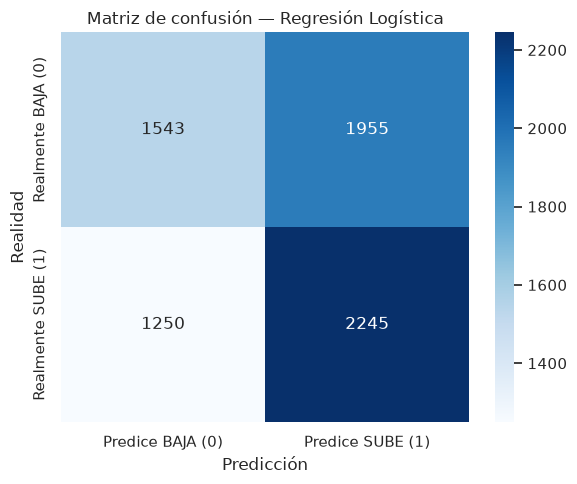

In [172]:
# Calculamos la matriz de confusión
matriz = confusion_matrix(y_test, pred_test)

# Extraemos los valores
tn = matriz[0, 0]  # true negative
fp = matriz[0, 1]  # false positive
fn = matriz[1, 0]  # false negative
tp = matriz[1, 1]  # true positive

print("Matriz de confusión:")
print(f"  TN (predijo baja, bajó):     {tn}")
print(f"  FP (predijo sube, bajó):     {fp}  ← perderías dinero aquí")
print(f"  FN (predijo baja, subió):    {fn}  ← oportunidad perdida")
print(f"  TP (predijo sube, subió):    {tp}  ← ganarías dinero aquí")

# Graficamos con heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predice BAJA (0)", "Predice SUBE (1)"],
            yticklabels=["Realmente BAJA (0)", "Realmente SUBE (1)"])
plt.title("Matriz de confusión — Regresión Logística")
plt.ylabel("Realidad")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

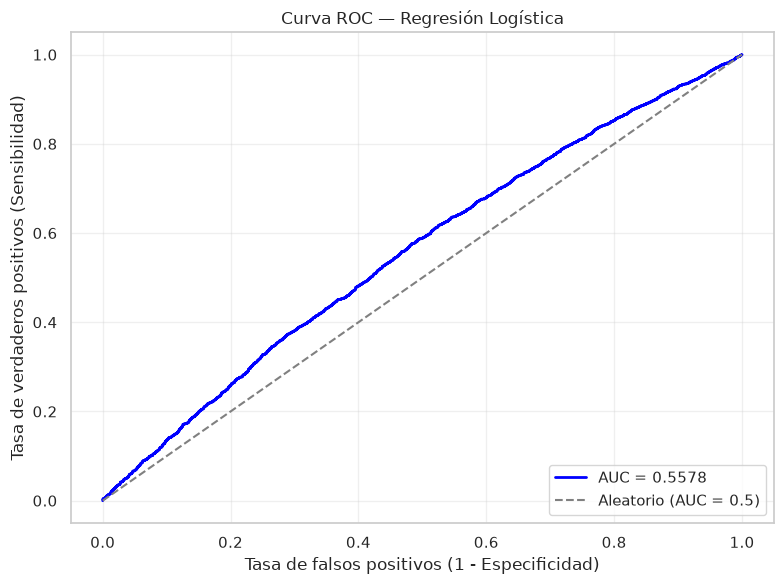

In [173]:
from sklearn.metrics import roc_curve

# Calculamos la curva ROC
fpr, tpr, umbrales = roc_curve(y_test, probs_test)
auc_valor = roc_auc_score(y_test, probs_test)

# Graficamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_valor:.4f}", color="blue", linewidth=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatorio (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos (1 - Especificidad)")
plt.ylabel("Tasa de verdaderos positivos (Sensibilidad)")
plt.title("Curva ROC — Regresión Logística")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [174]:
print(classification_report(y_test, pred_test,
                             target_names=["BAJA (0)", "SUBE (1)"]))

              precision    recall  f1-score   support

    BAJA (0)       0.55      0.44      0.49      3498
    SUBE (1)       0.53      0.64      0.58      3495

    accuracy                           0.54      6993
   macro avg       0.54      0.54      0.54      6993
weighted avg       0.54      0.54      0.54      6993



In [175]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Validación cruzada respetando el orden temporal
tscv = TimeSeriesSplit(n_splits=5)

# Grid de hiperparámetros
grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=grid_lr,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

print("Buscando mejores hiperparámetros...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor accuracy en validación cruzada: {grid_search.best_score_:.4f}")

# Evaluamos el modelo optimizado en test
modelo_optimizado = grid_search.best_estimator_
pred_test_opt = modelo_optimizado.predict(X_test_scaled)
accuracy_test_opt = accuracy_score(y_test, pred_test_opt)

print(f"\nComparación en test:")
print(f"  Modelo base:       {accuracy_score(y_test, pred_test):.4f}")
print(f"  Modelo optimizado: {accuracy_test_opt:.4f}")
print(f"  Mejora: {(accuracy_test_opt - accuracy_score(y_test, pred_test))*100:+.2f} puntos")

Buscando mejores hiperparámetros...


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty


Mejores hiperparámetros: {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor accuracy en validación cruzada: 0.5364

Comparación en test:
  Modelo base:       0.5417
  Modelo optimizado: 0.5410
  Mejora: -0.07 puntos


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [176]:
import joblib

joblib.dump(modelo_rl, "../modelos_ml/modelo_final.pkl")
joblib.dump(scaler, "../modelos_ml/scaler.pkl")
joblib.dump(features_finales, "../modelos_ml/features_finales.pkl")

print("Guardado OK")

Guardado OK
